# Cell 1: setup



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, zipfile, random
BASE = '/content/drive/MyDrive/pd-progression'
for sub in ['data/raw', 'data/processed', 'docs', 'models', 'reports']:
    os.makedirs(f'{BASE}/{sub}', exist_ok=True)

!pip install -q shap openpyxl

import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
from sklearn.model_selection import GroupKFold

random.seed(42)
np.random.seed(42)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 70)
print('ready | lightgbm', lgb.__version__, '| pandas', pd.__version__)

Mounted at /content/drive
ready | lightgbm 4.6.0 | pandas 2.2.3


# Cell 2: unzip

In [ ]:
RAW = f'{BASE}/data/raw'
zips = glob.glob(f'{RAW}/*.zip')
for z in zips:
    with zipfile.ZipFile(z) as f:
        f.extractall(RAW)
    print('unzipped:', os.path.basename(z))
print('zip files handled:', len(zips))

zip files handled: 0


# Cell 3: inventory of every file in raw

In [ ]:
files = sorted(glob.glob(f'{RAW}/**/*.*', recursive=True))
print(len(files), 'files\n')
for f in files:
    print(f'{os.path.getsize(f)/1e6:8.2f} MB  {os.path.relpath(f, RAW)}')

# Load all CSVs into a dict, schema only
tables = {}
for f in files:
    if f.lower().endswith('.csv'):
        name = os.path.basename(f).rsplit('.', 1)[0]
        try:
            df = pd.read_csv(f, low_memory=False)
        except UnicodeDecodeError:
            df = pd.read_csv(f, low_memory=False, encoding='latin-1')
        tables[name] = df

if tables:
    rows = []
    for name, df in tables.items():
        rows.append({
            'table': name[:50],
            'rows': len(df),
            'cols': df.shape[1],
            'PATNO': 'PATNO' in df.columns,
            'EVENT_ID': 'EVENT_ID' in df.columns,
            'patients': df['PATNO'].nunique() if 'PATNO' in df.columns else None,
        })
    print('\n', pd.DataFrame(rows).to_string(index=False))


def inspect(name, max_cols=60):
    df = tables[name]
    print(f'\n=== {name} === shape {df.shape}')
    info = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'pct_missing': (df.isna().mean() * 100).round(1),
        'n_unique': df.nunique(),
    })
    print(info.head(max_cols).to_string())


def find_col(keyword):
    kw = keyword.lower()
    hits = [(t, c) for t, df in tables.items() for c in df.columns if kw in c.lower()]
    for t, c in hits:
        print(f'{t[:50]:50s} -> {c}')
    if not hits:
        print('no match')

25 files

    1.07 MB  Age_at_visit_03Oct2026.csv
    0.56 MB  Code_List_-__Annotated__03Oct2026.csv
    0.99 MB  Data_Dictionary_-__Annotated__03Oct2026.csv
    1.55 MB  Demographics_03Oct2026.csv
    2.51 MB  Epworth_Sleepiness_Scale_03Oct2026.csv
    3.11 MB  Geriatric_Depression_Scale__Short_Version__02Oct2026.csv
    0.85 MB  Initiation_of_Dopaminergic_Therapy_03Oct2026.csv
    1.51 MB  LEDD_Concomitant_Medication_Log_02Oct2026.csv
   12.68 MB  MDS-UPDRS_Part_III_02Oct2026.csv
    1.56 MB  MDS-UPDRS_Part_IV__Motor_Complications_02Oct2026.csv
    3.70 MB  MDS-UPDRS_Part_I_02Oct2026.csv
    4.49 MB  MDS-UPDRS_Part_I_Patient_Questionnaire_02Oct2026.csv
    5.42 MB  MDS_UPDRS_Part_II__Patient_Questionnaire_02Oct2026.csv
    3.95 MB  Montreal_Cognitive_Assessment__MoCA__02Oct2026.csv
    0.27 MB  PD_Diagnosis_History_02Oct2026.csv
   15.65 MB  PPMI_Curated_Data_Cut_Public_20260810.xlsx
    4.28 MB  PPMI_Data_User_Guide_20260806.pdf
    0.19 MB  PPMI_Methods_LEDD_Levodopa_Equivalent_Dai

# Cell 4: curated data cut (the main table)

In [ ]:
cur_path = sorted(glob.glob(f'{RAW}/*urated*.xlsx'))[-1]
print('using:', os.path.basename(cur_path))

xl = pd.ExcelFile(cur_path)
print('sheets:', xl.sheet_names)

data = xl.parse(xl.sheet_names[0])       # participant data
dd = xl.parse('Data dictionary')         # one row per variable/code
info = xl.parse('Information', header=None)

print('\nDATA SHAPE:', data.shape)
print('\nDATA COLUMNS:')
print(list(data.columns))

# Inclusion criteria and notes text (not patient data)
print('\nINFORMATION TAB:')
for v in info.stack().astype(str).tolist():
    if len(v) > 40:
        print('-', v[:600])

# Dictionary: one line per variable
vars_ = dd[['Category', 'Variable', 'Description']].drop_duplicates('Variable')
print('\nvariables per category:')
print(vars_['Category'].value_counts().to_string())


def find(*keys):
    pat = '|'.join(keys)
    m = vars_[vars_['Variable'].astype(str).str.contains(pat, case=False, regex=True)
              | vars_['Description'].astype(str).str.contains(pat, case=False, regex=True)]
    print(m.to_string(index=False))


for k in ['updrs', 'hoehn|nhy', 'ledd', 'upsit', 'moca', 'sbr|datscan',
          'pigd|tremor', 'cohort|subgroup', 'visit|event|age|diagnosis']:
    print(f'\n=== {k} ===')
    find(k)

using: PPMI_Curated_Data_Cut_Public_20260810.xlsx
sheets: ['20260810', 'Data dictionary', 'Information']

DATA SHAPE: (20408, 215)

DATA COLUMNS:
['SITE', 'PATNO', 'COHORT', 'subgroup', 'enroll_phase', 'enroll_source', 'analytic_subgroup', 'HIQ_RBD', 'study_status', 'Death_Status', 'age_death', 'Death_Date', 'NSD_Status', 'NSD_STAGE', 'NSD_Adjudicated', 'Clinical_Stage', 'PRIMDIAG', 'OTHNEURO', 'EVENT_ID', 'YEAR', 'visit_date', 'age', 'age_at_visit', 'SEX', 'EDUCYRS', 'race', 'HISPLAT', 'ASHKJEW', 'AFICBERB', 'BASQUE', 'fampd', 'fampd_bin', 'handed', 'howlive', 'sex_orient', 'BMI', 'agediag', 'ageonset', 'duration', 'duration_yrs', 'DOMSIDE', 'sym_tremor', 'sym_rigid', 'sym_brady', 'sym_posins', 'sym_other', 'sym_unknown', 'PDTRTMNT', 'LEDD', 'age_datscan', 'age_LP', 'age_upsit', 'upsit', 'upsit_pctl', 'upsit_pctl15', 'moca', 'bjlot', 'DVS_JLO_MSSA', 'DVS_JLO_MSSAE', 'clockdraw', 'DVT_CLCKDRAW', 'DVZ_CLCKDRAW', 'hvlt_discrimination', 'hvlt_immediaterecall', 'hvlt_retention', 'HVLTFPRL'

# Cell 5: find the PD cohort and check that the target is usable



In [ ]:
# 1. Raw cohort values actually present in the data
print('COHORT value counts (rows):')
print(data['COHORT'].value_counts(dropna=False).to_string())

# 2. Full decode table (variable names are only filled on the first row of each block)
dd2 = dd.copy()
dd2['Variable'] = dd2['Variable'].ffill()
cd = dd2[dd2['Variable'].eq('COHORT')][['Code', 'Decode']].dropna(how='all')
print('\nCOHORT decode:')
print(cd.to_string(index=False))

# 3. Pick PD codes: "PD Participant" and "Early Imaging"
pd_codes = []
for c, d in zip(cd['Code'], cd['Decode']):
    if pd.isna(c):
        continue
    t = str(d).lower()
    if 'pd participant' in t or 'early imaging' in t:
        pd_codes.append(str(c).split('.')[0])
print('\nPD-type codes:', pd_codes)

def is_pd(v):
    s = str(v).split('.')[0]
    return s in pd_codes

pdd = data[data['COHORT'].map(is_pd)].copy()
print('\nPD-cohort participants:', pdd['PATNO'].nunique())
print('rows:', len(pdd))
print('duplicate (PATNO, EVENT_ID) rows:', pdd.duplicated(['PATNO', 'EVENT_ID']).sum())

print('\nsubgroup counts (participants):')
print(pdd.drop_duplicates('PATNO')['subgroup'].value_counts(dropna=False).to_string())

# 4. Motor score availability by visit
rows = []
for e in ['BL', 'V04', 'V06', 'V08', 'V10', 'V12']:
    s = pdd[pdd['EVENT_ID'] == e]
    rows.append({'EVENT_ID': e,
                 'participants': s['PATNO'].nunique(),
                 'has_updrs3_OFF': int(s['updrs3_score'].notna().sum()),
                 'has_updrs3_ON': int(s['updrs3_score_on'].notna().sum())})
print('\n', pd.DataFrame(rows).to_string(index=False))

# 5. Usable baseline + month-24 pairs
def pair_count(col, end='V06'):
    a = pdd[pdd['EVENT_ID'] == 'BL'].drop_duplicates('PATNO').set_index('PATNO')[col].dropna()
    b = pdd[pdd['EVENT_ID'] == end].drop_duplicates('PATNO').set_index('PATNO')[col].dropna()
    return len(a.index.intersection(b.index))

for col in ['updrs3_score', 'updrs3_score_on']:
    print(f'{col}: BL + V06 pairs =', pair_count(col))

# 6. Is V06 really about 24 months after baseline?
bl_age = pdd[pdd['EVENT_ID'] == 'BL'].drop_duplicates('PATNO').set_index('PATNO')['age_at_visit']
v6_age = pdd[pdd['EVENT_ID'] == 'V06'].drop_duplicates('PATNO').set_index('PATNO')['age_at_visit']
gap_months = ((v6_age - bl_age) * 12).dropna()
print('\nmonths between BL and V06 (from age at visit):')
print(gap_months.describe().round(1).to_string())

COHORT value counts (rows):
COHORT
4    9428
1    8546
2    2233
3     201

COHORT decode:
Code          Decode
   1  PD Participant
   2 Healthy Control
   3           SWEDD
   4      Prodromal 

PD-type codes: ['1']

PD-cohort participants: 1684
rows: 8546
duplicate (PATNO, EVENT_ID) rows: 0

subgroup counts (participants):
subgroup
Sporadic PD                         1080
PD Normosmic                         206
LRRK2 PD                             189
GBA PD                               115
SNCA PD                               39
PRKN PD                               30
LRRK2 and GBA PD                       9
LRRK2 PD Normosmic                     6
Other Genetic Variant PD               4
PINK1 PD                               3
GBA PD Normosmic                       2
GBA and Other Genetic Variant PD       1

 EVENT_ID  participants  has_updrs3_OFF  has_updrs3_ON
      BL          1684            1550           1644
     V04          1298            1069           1233
     V0

# Cell 6: build the modeling table


In [ ]:
TARGET_VISIT = 'V06'
TARGET_COL = 'updrs3_score'      # OFF and untreated; use 'updrs3_score_on' if the sample is too small

sub = pdd[pdd['EVENT_ID'].isin(['BL', TARGET_VISIT])]
bl = sub[sub['EVENT_ID'] == 'BL'].drop_duplicates('PATNO').set_index('PATNO')
fu = sub[sub['EVENT_ID'] == TARGET_VISIT].drop_duplicates('PATNO').set_index('PATNO')

ids = bl.index[bl[TARGET_COL].notna()].intersection(fu.index[fu[TARGET_COL].notna()])
X = bl.loc[ids].copy()
y = (fu.loc[ids, TARGET_COL] - bl.loc[ids, TARGET_COL]).rename('target_delta')
qc_gap = ((fu.loc[ids, 'age_at_visit'] - bl.loc[ids, 'age_at_visit']) * 12).rename('qc_gap_months')

# Columns that must never be features
DROP = ['SITE', 'EVENT_ID', 'YEAR', 'visit_date', 'study_status', 'Death_Status', 'age_death',
        'Death_Date', 'NSD_Status', 'NSD_STAGE', 'NSD_Adjudicated', 'Clinical_Stage', 'PRIMDIAG',
        'OTHNEURO', 'enroll_source', 'enroll_phase', 'COHORT', 'analytic_subgroup', 'HIQ_RBD']
DROP += [c for c in X.columns if c.startswith(('pm_', 'Stage_'))]
feat = X.drop(columns=[c for c in DROP if c in X.columns])

# Treatment flags (untreated patients have no LEDD record, so missing is not random)
ledd_missing = X['LEDD'].isna().astype(int) if 'LEDD' in X.columns else None

# Keep columns with at least 40% data at baseline, but always keep LEDD
keep = list(feat.columns[feat.notna().mean() >= 0.4])
if 'LEDD' in feat.columns and 'LEDD' not in keep:
    keep.append('LEDD')
feat = feat[keep].copy()

# Fix types: numeric strings become numbers, short text becomes category, the rest is dropped
for c in list(feat.columns):
    if feat[c].dtype == 'object':
        num = pd.to_numeric(feat[c], errors='coerce')
        if num.notna().sum() >= 0.9 * feat[c].notna().sum():
            feat[c] = num
        elif feat[c].nunique() <= 30:
            feat[c] = feat[c].astype('category')
        else:
            feat = feat.drop(columns=c)

if ledd_missing is not None:
    feat['ledd_missing'] = ledd_missing

out = feat.copy()
out['target_delta'] = y
out.index.name = 'PATNO'
out.to_pickle(f'{BASE}/data/processed/pd_model_{TARGET_COL}_{TARGET_VISIT}.pkl')

print('participants in table:', len(out))
print('features:', feat.shape[1])
print('\ntarget (24-month change in Part III):')
print(y.describe().round(2).to_string())
print('\nqc: months between baseline and target visit:')
print(qc_gap.describe().round(1).to_string())
print('\nfeature list:')
print(list(feat.columns))
print('\nmost missing features (% missing):')
print((feat.isna().mean() * 100).round(0).sort_values(ascending=False).head(15).to_string())

participants in table: 880
features: 156

target (24-month change in Part III):
count    880.00
mean       4.50
std       10.08
min      -32.00
25%       -2.00
50%        4.00
75%       11.00
max       46.00

qc: months between baseline and target visit:
count    880.0
mean      24.8
std        1.7
min        2.5
25%       23.9
50%       24.4
75%       25.3
max       36.1

feature list:
['subgroup', 'age', 'age_at_visit', 'SEX', 'EDUCYRS', 'race', 'HISPLAT', 'ASHKJEW', 'AFICBERB', 'BASQUE', 'fampd', 'fampd_bin', 'handed', 'BMI', 'agediag', 'ageonset', 'duration', 'duration_yrs', 'DOMSIDE', 'sym_tremor', 'sym_rigid', 'sym_brady', 'sym_posins', 'sym_other', 'sym_unknown', 'PDTRTMNT', 'LEDD', 'age_datscan', 'age_LP', 'age_upsit', 'upsit', 'upsit_pctl', 'upsit_pctl15', 'moca', 'bjlot', 'DVS_JLO_MSSA', 'DVS_JLO_MSSAE', 'clockdraw', 'DVT_CLCKDRAW', 'DVZ_CLCKDRAW', 'hvlt_discrimination', 'hvlt_immediaterecall', 'hvlt_retention', 'HVLTFPRL', 'HVLTRDLY', 'HVLTREC', 'DVT_TOTAL_RECALL', 'DVT_DELA

# Cell 7: baselines, LightGBM, SHAP

kept 867 of 880 | removed 13
136 numeric features, 3 categorical features
Spearman(baseline Part III, change): -0.259


/tmp/ipykernel_3576/1413157488.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'Spearman': spearmanr(yt, yp)[0] if np.std(yp) > 0 else np.nan}
/tmp/ipykernel_3576/1413157488.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'Spearman': spearmanr(yt, yp)[0] if np.std(yp) > 0 else np.nan}
/tmp/ipykernel_3576/1413157488.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'Spearman': spearmanr(yt, yp)[0] if np.std(yp) > 0 else np.nan}
/tmp/ipykernel_3576/1413157488.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'Spearman': spearmanr(yt, yp)[0] if np.std(yp) > 0 else np.nan}
/tmp/ipykernel_3576/1413157488.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'Spearman': spearmanr(yt, yp)[0] if np.std(yp) > 0 else np.nan}
/tmp/ipyke


                           MAE           RMSE            R2        Spearman       
                         mean    std    mean    std   mean    std     mean    std
model                                                                            
1_mean_change           7.726  0.433  10.070  0.753 -0.007  0.010      NaN    NaN
2_baseline_updrs3_only  7.547  0.361   9.675  0.603  0.068  0.051    0.257  0.086
3_ridge_all_numeric     7.530  0.419   9.770  0.740  0.052  0.037    0.254  0.073
4_lightgbm              7.597  0.385   9.842  0.647  0.035  0.069    0.264  0.081

Top 15 features by mean |SHAP| (points of change in Part III):
updrs3_score         1.397
updrs_totscore       0.447
updrs3_score_on      0.447
IU_ABeta42_CSF       0.434
MIA_PUTAMEN_L        0.402
DVS_BNT              0.358
DVZ_TMTB             0.314
EDUCYRS              0.300
META5_proxy_PGS      0.292
MIA_CAUDATE_R        0.288
TMT_B                0.279
stai_state           0.270
DVS_JLO_MSSAE        0.230
IU_ABeta4

/tmp/ipykernel_3576/1413157488.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X, plot_type='bar', max_display=15, show=False)


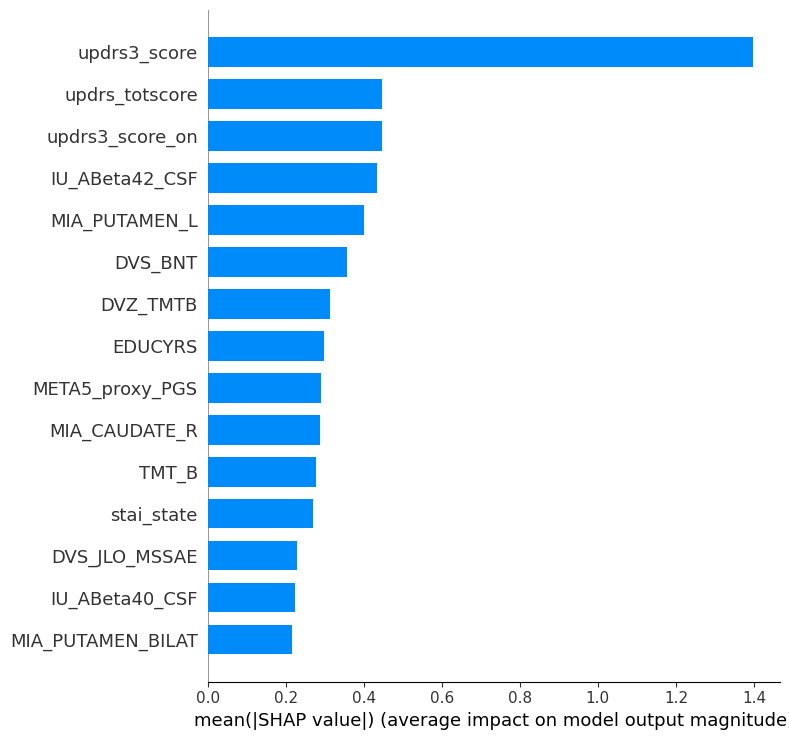

In [ ]:
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# 1. Keep follow-up close to 24 months
ok = qc_gap.reindex(out.index).between(18, 30)
tab = out[ok].copy()
print('kept', int(ok.sum()), 'of', len(ok), '| removed', int((~ok).sum()))

y = tab['target_delta'].astype(float)
X = tab.drop(columns='target_delta')

# 2. Remove columns that should not be features
DROP_MORE = ['race', 'HISPLAT', 'ASHKJEW', 'AFICBERB', 'BASQUE',
             'age_datscan', 'age_LP', 'age_upsit',
             'CSFSAA_assay', 'MTBR_TAU243_InstErr', 'age', 'duration']
DROP_MORE += [c for c in X.columns if c.endswith(('_LLOD', '_ULOD'))]
X = X.drop(columns=[c for c in DROP_MORE if c in X.columns])

cats = [c for c in X.columns if str(X[c].dtype) == 'category']
nums = [c for c in X.columns if c not in cats]
X[nums] = X[nums].apply(pd.to_numeric, errors='coerce')
print(len(nums), 'numeric features,', len(cats), 'categorical features')
assert X.index.is_unique   # one row per patient, so shuffled KFold is already patient-level

print('Spearman(baseline Part III, change):',
      np.round(spearmanr(X['updrs3_score'], y)[0], 3))

# 3. Cross-validation (5 folds x 3 repeats)
def metrics(yt, yp):
    return {'MAE': mean_absolute_error(yt, yp),
            'RMSE': mean_squared_error(yt, yp) ** 0.5,
            'R2': r2_score(yt, yp),
            'Spearman': spearmanr(yt, yp)[0] if np.std(yp) > 0 else np.nan}

lgb_params = dict(n_estimators=300, learning_rate=0.03, num_leaves=7, max_depth=3,
                  min_child_samples=25, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.6, reg_lambda=5.0, random_state=42, verbose=-1)

rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
rows = []
for k, (tr, te) in enumerate(rkf.split(X)):
    Xtr, Xte, ytr, yte = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]

    # a) predict the training mean for everyone
    rows.append({'model': '1_mean_change', **metrics(yte, np.full(len(yte), ytr.mean()))})

    # b) linear model on baseline Part III only
    m = LinearRegression().fit(Xtr[['updrs3_score']], ytr)
    rows.append({'model': '2_baseline_updrs3_only', **metrics(yte, m.predict(Xte[['updrs3_score']]))})

    # c) ridge on all numeric features
    rg = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                       RidgeCV(alphas=[1, 10, 100, 300, 1000, 3000]))
    rg.fit(Xtr[nums], ytr)
    rows.append({'model': '3_ridge_all_numeric', **metrics(yte, rg.predict(Xte[nums]))})

    # d) LightGBM on everything
    gb = lgb.LGBMRegressor(**lgb_params).fit(Xtr, ytr)
    rows.append({'model': '4_lightgbm', **metrics(yte, gb.predict(Xte))})

res = pd.DataFrame(rows)
summary = res.groupby('model').agg(['mean', 'std']).round(3)
print('\n', summary.to_string())
res.to_csv(f'{BASE}/reports/cv_results_{TARGET_COL}_{TARGET_VISIT}.csv', index=False)

# 4. SHAP on a model fit to all patients (for explanation only, not for scoring)
gb_full = lgb.LGBMRegressor(**lgb_params).fit(X, y)
try:
    explainer = shap.TreeExplainer(gb_full)
    sv = explainer.shap_values(X)
    imp = pd.Series(np.abs(sv).mean(axis=0), index=X.columns).sort_values(ascending=False)
    print('\nTop 15 features by mean |SHAP| (points of change in Part III):')
    print(imp.head(15).round(3).to_string())

    shap.summary_plot(sv, X, plot_type='bar', max_display=15, show=False)
    plt.tight_layout()
    plt.savefig(f'{BASE}/reports/shap_bar.png', dpi=200)
    plt.show()
except Exception as e:
    print('SHAP step failed:', e)

# Cell 8: slope target

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# 1. Per-patient slope of Part III (OFF/untreated) over months since baseline
bl_all = pdd[pdd['EVENT_ID'] == 'BL'].drop_duplicates('PATNO').set_index('PATNO')
bl_age = bl_all['age_at_visit']

long = pdd[['PATNO', 'EVENT_ID', 'age_at_visit', 'updrs3_score']].dropna().copy()
long = long[long['EVENT_ID'].str.match(r'^(BL|V\d\d)$')]
long['months'] = (long['age_at_visit'] - long['PATNO'].map(bl_age)) * 12
long = long[(long['months'] >= 0) & (long['months'] <= 48)]

def slope_per_year(g):
    if len(g) < 3 or g['months'].max() < 18 or g['months'].min() > 1:
        return np.nan
    return np.polyfit(g['months'], g['updrs3_score'], 1)[0] * 12

sl = long.groupby('PATNO').apply(slope_per_year).dropna()

idx = sl.index.intersection(bl_all.index[bl_all['updrs3_score'].notna()])
print('patients with a slope:', len(idx))
print('\nslope (points per year):')
print(sl.loc[idx].describe().round(2).to_string())

# 2. Baseline features for these patients (same columns as before)
cols = [c for c in X.columns if c in bl_all.columns]
Xs = bl_all.loc[idx, cols].copy()
Xs['ledd_missing'] = bl_all.loc[idx, 'LEDD'].isna().astype(int)
for c in nums:
    if c in Xs.columns:
        Xs[c] = pd.to_numeric(Xs[c], errors='coerce')
for c in cats:
    if c in Xs.columns:
        Xs[c] = Xs[c].astype('category')
Xs = Xs[X.columns]
ys = sl.loc[idx].astype(float)

# 3. Same models and same cross-validation
rows = []
for tr, te in rkf.split(Xs):
    Xtr, Xte, ytr, yte = Xs.iloc[tr], Xs.iloc[te], ys.iloc[tr], ys.iloc[te]
    rows.append({'model': '1_mean', **metrics(yte, np.full(len(yte), ytr.mean()))})

    m = LinearRegression().fit(Xtr[['updrs3_score']], ytr)
    rows.append({'model': '2_baseline_only', **metrics(yte, m.predict(Xte[['updrs3_score']]))})

    rg = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                       RidgeCV(alphas=[1, 10, 100, 300, 1000, 3000]))
    rg.fit(Xtr[nums], ytr)
    rows.append({'model': '3_ridge', **metrics(yte, rg.predict(Xte[nums]))})

    gb = lgb.LGBMRegressor(**lgb_params).fit(Xtr, ytr)
    rows.append({'model': '4_lightgbm', **metrics(yte, gb.predict(Xte))})

res2 = pd.DataFrame(rows)
print('\n', res2.groupby('model').agg(['mean', 'std']).round(3).to_string())
res2.to_csv(f'{BASE}/reports/cv_results_slope.csv', index=False)

# 4. SHAP for the slope model (explanation only)
gb_full = lgb.LGBMRegressor(**lgb_params).fit(Xs, ys)
sv = shap.TreeExplainer(gb_full).shap_values(Xs)
imp = pd.Series(np.abs(sv).mean(axis=0), index=Xs.columns).sort_values(ascending=False)
print('\nTop 12 features by mean |SHAP| (points per year):')
print(imp.head(12).round(3).to_string())

patients with a slope: 912

slope (points per year):
count    912.00
mean       2.05
std        4.00
min      -12.27
25%       -0.50
50%        1.88
75%        4.48
max       23.41

                    MAE           RMSE              R2          Spearman       
                  mean    std    mean     std    mean      std     mean    std
model                                                                         
1_mean           3.043  0.102   4.002   0.142  -0.008    0.014      NaN    NaN
2_baseline_only  2.960  0.116   3.863   0.159   0.061    0.035    0.258  0.058
3_ridge          4.125  2.432  19.107  31.829 -87.780  190.591    0.279  0.076
4_lightgbm       2.988  0.138   3.911   0.163   0.036    0.063    0.261  0.079

Top 12 features by mean |SHAP| (points per year):
updrs3_score       0.561
BMI                0.218
updrs3_score_on    0.209
stai_state         0.182
DVZ_TMTB           0.157
TMT_B              0.152
META5_proxy_PGS    0.151
updrs_totscore     0.114
MIA_CAUDATE_L

# Cell 9

In [ ]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import FunctionTransformer

LM = 'V04'   # landmark visit (about month 12)

bl_all = pdd[pdd['EVENT_ID'] == 'BL'].drop_duplicates('PATNO').set_index('PATNO')
lm = pdd[pdd['EVENT_ID'] == LM].drop_duplicates('PATNO').set_index('PATNO')
bl_age = bl_all['age_at_visit']

# 1. Target: slope using only visits AFTER the landmark
tmp = pdd[['PATNO', 'EVENT_ID', 'age_at_visit', 'updrs3_score']].dropna().copy()
tmp['months'] = (tmp['age_at_visit'] - tmp['PATNO'].map(bl_age)) * 12
post = tmp[tmp['EVENT_ID'].str.match(r'^V\d\d$') & (tmp['months'] > 14) & (tmp['months'] <= 60)]

def post_slope(g):
    if len(g) < 3 or g['months'].max() - g['months'].min() < 18:
        return np.nan
    return np.polyfit(g['months'], g['updrs3_score'], 1)[0] * 12

ys_all = post.groupby('PATNO').apply(post_slope).dropna()

# 2. Patients with a baseline score, a landmark score, and a landmark about 9 to 18 months in
idx = (ys_all.index
       .intersection(bl_all.index[bl_all['updrs3_score'].notna()])
       .intersection(lm.index[lm['updrs3_score'].notna()]))
lm_months = (lm.loc[idx, 'age_at_visit'] - bl_age.loc[idx]) * 12
idx = lm_months.index[lm_months.between(9, 18)]
lm_months = lm_months.loc[idx]
print('patients in landmark analysis:', len(idx))

# 3. Features: baseline columns + what is known at the landmark
cols = [c for c in X.columns if c in bl_all.columns]
XL = bl_all.loc[idx, cols].copy()
XL['ledd_missing'] = bl_all.loc[idx, 'LEDD'].isna().astype(int)
for c in nums:
    if c in XL.columns:
        XL[c] = pd.to_numeric(XL[c], errors='coerce')
for c in cats:
    if c in XL.columns:
        XL[c] = XL[c].astype('category')

XL['lm_updrs3'] = lm.loc[idx, 'updrs3_score']
XL['lm_updrs3_on'] = pd.to_numeric(lm.loc[idx, 'updrs3_score_on'], errors='coerce')
XL['lm_moca'] = pd.to_numeric(lm.loc[idx, 'moca'], errors='coerce')
XL['lm_NHY'] = pd.to_numeric(lm.loc[idx, 'NHY'], errors='coerce')
XL['lm_pigd'] = pd.to_numeric(lm.loc[idx, 'pigd'], errors='coerce')
XL['lm_LEDD'] = pd.to_numeric(lm.loc[idx, 'LEDD'], errors='coerce')
XL['lm_months'] = lm_months
XL['early_delta'] = XL['lm_updrs3'] - XL['updrs3_score']
XL['early_slope'] = XL['early_delta'] / XL['lm_months'] * 12

yL = ys_all.loc[idx].astype(float)
numsL = [c for c in XL.columns if str(XL[c].dtype) != 'category']

print('\ntarget: slope after landmark (points per year)')
print(yL.describe().round(2).to_string())
print('Spearman(early_slope, later slope):',
      np.round(spearmanr(XL['early_slope'], yL)[0], 3))

# 4. Models and cross-validation
clip = FunctionTransformer(lambda a: np.clip(a, -5, 5))
def ridge_model():
    return make_pipeline(SimpleImputer(strategy='median'), VarianceThreshold(1e-8),
                         StandardScaler(), clip,
                         RidgeCV(alphas=[10, 100, 300, 1000, 3000, 10000]))

rows = []
for tr, te in rkf.split(XL):
    Xtr, Xte, ytr, yte = XL.iloc[tr], XL.iloc[te], yL.iloc[tr], yL.iloc[te]
    rows.append({'model': '1_mean', **metrics(yte, np.full(len(yte), ytr.mean()))})

    f1 = ['lm_updrs3']
    m = LinearRegression().fit(Xtr[f1], ytr)
    rows.append({'model': '2_landmark_score_only', **metrics(yte, m.predict(Xte[f1]))})

    f2 = ['lm_updrs3', 'updrs3_score', 'early_slope']
    m = LinearRegression().fit(Xtr[f2], ytr)
    rows.append({'model': '3_score+baseline+early_slope', **metrics(yte, m.predict(Xte[f2]))})

    rg = ridge_model().fit(Xtr[numsL], ytr)
    rows.append({'model': '4_ridge_all', **metrics(yte, rg.predict(Xte[numsL]))})

    gb = lgb.LGBMRegressor(**lgb_params).fit(Xtr, ytr)
    rows.append({'model': '5_lightgbm_all', **metrics(yte, gb.predict(Xte))})

resL = pd.DataFrame(rows)
print('\n', resL.groupby('model').agg(['mean', 'std']).round(3).to_string())
resL.to_csv(f'{BASE}/reports/cv_results_landmark.csv', index=False)

# 5. SHAP (explanation only)
gb_full = lgb.LGBMRegressor(**lgb_params).fit(XL, yL)
sv = shap.TreeExplainer(gb_full).shap_values(XL)
imp = pd.Series(np.abs(sv).mean(axis=0), index=XL.columns).sort_values(ascending=False)
print('\nTop 12 features by mean |SHAP| (points per year):')
print(imp.head(12).round(3).to_string())

patients in landmark analysis: 392

target: slope after landmark (points per year)
count    392.00
mean       1.84
std        4.48
min      -16.65
25%       -1.02
50%        1.91
75%        4.72
max       14.90
Spearman(early_slope, later slope): 0.008

                                 MAE          RMSE            R2        Spearman       
                               mean    std   mean    std   mean    std     mean    std
model                                                                                 
1_mean                        3.513  0.301  4.473  0.348 -0.011  0.011      NaN    NaN
2_landmark_score_only         3.520  0.299  4.484  0.347 -0.016  0.012   -0.012  0.113
3_score+baseline+early_slope  3.544  0.305  4.511  0.340 -0.029  0.025   -0.030  0.100
4_ridge_all                   3.525  0.314  4.483  0.351 -0.016  0.023   -0.003  0.155
5_lightgbm_all                3.819  0.316  4.791  0.385 -0.163  0.090   -0.022  0.094

Top 12 features by mean |SHAP| (points per year)

# Cell 10

In [ ]:
import warnings
warnings.filterwarnings('ignore')

def landmark_run(series_col, LM='V04', min_post=3, lo=9, hi=18):
    bl_all = pdd[pdd['EVENT_ID'] == 'BL'].drop_duplicates('PATNO').set_index('PATNO')
    lm = pdd[pdd['EVENT_ID'] == LM].drop_duplicates('PATNO').set_index('PATNO')
    bl_age = bl_all['age_at_visit']

    tmp = pdd[['PATNO', 'EVENT_ID', 'age_at_visit', series_col]].dropna().copy()
    tmp['months'] = (tmp['age_at_visit'] - tmp['PATNO'].map(bl_age)) * 12
    post = tmp[tmp['EVENT_ID'].str.match(r'^V\d\d$') & (tmp['months'] > 14) & (tmp['months'] <= 60)]

    def post_slope(g):
        if len(g) < min_post or g['months'].max() - g['months'].min() < 18:
            return np.nan
        return np.polyfit(g['months'], g[series_col], 1)[0] * 12

    ys_all = post.groupby('PATNO').apply(post_slope).dropna()
    idx = (ys_all.index
           .intersection(bl_all.index[bl_all[series_col].notna()])
           .intersection(lm.index[lm[series_col].notna()]))
    lm_months = (lm.loc[idx, 'age_at_visit'] - bl_age.loc[idx]) * 12
    idx = lm_months.index[lm_months.between(lo, hi)]
    lm_months = lm_months.loc[idx]

    cols = [c for c in X.columns if c in bl_all.columns]
    XL = bl_all.loc[idx, cols].copy()
    XL['ledd_missing'] = bl_all.loc[idx, 'LEDD'].isna().astype(int)
    for c in nums:
        if c in XL.columns:
            XL[c] = pd.to_numeric(XL[c], errors='coerce')
    for c in cats:
        if c in XL.columns:
            XL[c] = XL[c].astype('category')

    XL['lm_series'] = pd.to_numeric(lm.loc[idx, series_col], errors='coerce')
    XL['lm_months'] = lm_months
    XL['early_slope'] = (XL['lm_series'] - pd.to_numeric(bl_all.loc[idx, series_col], errors='coerce')) / XL['lm_months'] * 12
    yL = ys_all.loc[idx].astype(float)
    numsL = [c for c in XL.columns if str(XL[c].dtype) != 'category']

    print(f'\n########## target series: {series_col} ##########')
    print('patients:', len(idx))
    print('slope after landmark (points/year):')
    print(yL.describe().round(2).to_string())
    print('Spearman(early_slope, later slope):', np.round(spearmanr(XL['early_slope'], yL)[0], 3))

    rows = []
    for tr, te in rkf.split(XL):
        Xtr, Xte, ytr, yte = XL.iloc[tr], XL.iloc[te], yL.iloc[tr], yL.iloc[te]
        rows.append({'model': '1_mean', **metrics(yte, np.full(len(yte), ytr.mean()))})

        f1 = ['lm_series']
        m = LinearRegression().fit(Xtr[f1].fillna(Xtr[f1].median()), ytr)
        rows.append({'model': '2_landmark_score_only',
                     **metrics(yte, m.predict(Xte[f1].fillna(Xtr[f1].median())))})

        f2 = ['lm_series', 'early_slope']
        med = Xtr[f2].median()
        m = LinearRegression().fit(Xtr[f2].fillna(med), ytr)
        rows.append({'model': '3_score+early_slope', **metrics(yte, m.predict(Xte[f2].fillna(med)))})

        rg = make_pipeline(SimpleImputer(strategy='median'), VarianceThreshold(1e-8),
                           StandardScaler(), FunctionTransformer(lambda a: np.clip(a, -5, 5)),
                           RidgeCV(alphas=[10, 100, 300, 1000, 3000, 10000]))
        rg.fit(Xtr[numsL], ytr)
        rows.append({'model': '4_ridge_all', **metrics(yte, rg.predict(Xte[numsL]))})

        gb = lgb.LGBMRegressor(**lgb_params).fit(Xtr, ytr)
        rows.append({'model': '5_lightgbm_all', **metrics(yte, gb.predict(Xte))})

    res = pd.DataFrame(rows)
    print(res.groupby('model').agg(['mean', 'std']).round(3).to_string())
    res.to_csv(f'{BASE}/reports/cv_landmark_{series_col}.csv', index=False)
    return XL, yL

XL2, yL2 = landmark_run('updrs2_score')
XL3, yL3 = landmark_run('updrs3_score_on')


########## target series: updrs2_score ##########
patients: 652
slope after landmark (points/year):
count    652.00
mean       0.92
std        2.20
min       -8.91
25%       -0.41
50%        0.76
75%        2.03
max       13.14
Spearman(early_slope, later slope): -0.004
                         MAE          RMSE            R2        Spearman       
                        mean    std   mean    std   mean    std     mean    std
model                                                                          
1_mean                 1.600  0.103  2.200  0.153 -0.011  0.006      NaN    NaN
2_landmark_score_only  1.604  0.102  2.209  0.153 -0.020  0.021    0.007  0.089
3_score+early_slope    1.608  0.101  2.217  0.154 -0.027  0.025   -0.019  0.070
4_ridge_all            1.599  0.102  2.198  0.150 -0.010  0.014    0.058  0.100
5_lightgbm_all         1.634  0.094  2.230  0.111 -0.044  0.082    0.117  0.083

########## target series: updrs3_score_on ##########
patients: 547
slope after landmark

# Cell 11

In [ ]:
# A) What are the milestone variables, and how are they coded?
dd2 = dd.copy()
dd2['Variable'] = dd2['Variable'].ffill()
pm_cols = [c for c in data.columns if c.startswith('pm_')]
print('milestone columns:', pm_cols)

for c in pm_cols:
    blk = dd2[dd2['Variable'].eq(c)]
    desc = blk['Description'].dropna().iloc[0] if blk['Description'].notna().any() else ''
    notes = blk['Derivation Notes'].dropna().iloc[0] if 'Derivation Notes' in blk and blk['Derivation Notes'].notna().any() else ''
    print(f'\n{c} | {desc}')
    print('   notes:', str(notes)[:400])
    print('   codes:', blk[['Code', 'Decode']].dropna(how='all').values.tolist()[:6])

# B) Prevalence by visit in the PD cohort (participants with a value)
rows = []
for e in ['BL', 'V04', 'V06', 'V08', 'V10', 'V12']:
    s = pdd[pdd['EVENT_ID'] == e]
    r = {'EVENT_ID': e}
    for c in pm_cols:
        v = pd.to_numeric(s[c], errors='coerce')
        r[c + '_n'] = int(v.notna().sum())
        r[c + '_%'] = round(float(v.mean() * 100), 1) if v.notna().any() else None
    rows.append(r)
print('\n', pd.DataFrame(rows).T.to_string())

# C) Once a flag is 1, does it ever drop back to 0 later?
for c in ['pm_any', 'pm_cog_any']:
    vv = pdd[['PATNO', 'age_at_visit', c]].copy()
    vv[c] = pd.to_numeric(vv[c], errors='coerce')
    vv = vv.dropna().sort_values(['PATNO', 'age_at_visit'])
    vv['prev'] = vv.groupby('PATNO')[c].shift()
    drops = int(((vv['prev'] == 1) & (vv[c] == 0)).sum())
    print(f'{c}: rows where the flag drops 1 -> 0: {drops} of {int(vv["prev"].notna().sum())}')

# D) MoCA decline with the same landmark test
XL4, yL4 = landmark_run('moca', min_post=2)

milestone columns: ['pm_any', 'pm_adl_any', 'pm_fd_any', 'pm_auto_any', 'pm_cog_any', 'pm_mc_any', 'pm_wb_any']

pm_any | Progression Milestones - Indicator for any milestone (any domain)
   notes: See Table 1 in publication by Brumm, et al. (2023) (doi:10.3233/JPD-223433)
   codes: [[0, 'No'], [1, 'Yes'], ['.', 'Unknown']]

pm_adl_any | Progression Milestones - Indicator for any activities of daily living milestone
   notes: See Table 1 in publication by Brumm, et al. (2023) (doi:10.3233/JPD-223433)
   codes: [[0, 'No'], [1, 'Yes'], ['.', 'Unknown']]

pm_fd_any | Progression Milestones - Indicator for any functional dependence milestone
   notes: See Table 1 in publication by Brumm, et al. (2023) (doi:10.3233/JPD-223433)
   codes: [[0, 'No'], [1, 'Yes'], ['.', 'Unknown']]

pm_auto_any | Progression Milestones - Indicator for any autonomic dysfunction milestone
   notes: See Table 1 in publication by Brumm, et al. (2023) (doi:10.3233/JPD-223433)
   codes: [[0, 'No'], [1, 'Yes'], ['.', 

# Cell 12


In [ ]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

HORIZON, MIN_FU = 40, 30      # months
SMALL = ['age_at_visit', 'duration_yrs', 'updrs2_score', 'updrs3_score', 'moca', 'LEDD', 'ledd_missing']

bl_all = pdd[pdd['EVENT_ID'] == 'BL'].drop_duplicates('PATNO').set_index('PATNO')
bl_age = bl_all['age_at_visit']

def build_milestone(flag):
    v = pdd[['PATNO', 'EVENT_ID', 'age_at_visit', flag]].copy()
    v[flag] = pd.to_numeric(v[flag], errors='coerce')            # '.' (Unknown) becomes NaN
    v = v.dropna(subset=['age_at_visit', flag])
    v = v[v['EVENT_ID'].str.match(r'^(BL|V\d\d)$')]
    v['months'] = (v['age_at_visit'] - v['PATNO'].map(bl_age)) * 12

    free = v[(v['EVENT_ID'] == 'BL') & (v[flag] == 0)]['PATNO'].unique()
    fu = v[v['PATNO'].isin(free) & (v['months'] > 0) & (v['months'] <= HORIZON)]
    ev = fu.groupby('PATNO')[flag].max().reindex(free)            # NaN if no follow-up row
    last = fu.groupby('PATNO')['months'].max().reindex(free)

    keep = ev.notna() & ((ev == 1) | (last >= MIN_FU))
    idx = ev.index[keep]
    return idx, ev.loc[idx].astype(int), len(free)

def prep_features(idx):
    cols = [c for c in X.columns if c in bl_all.columns]
    F = bl_all.loc[idx, cols].copy()
    F['ledd_missing'] = bl_all.loc[idx, 'LEDD'].isna().astype(int)
    for c in nums:
        if c in F.columns:
            F[c] = pd.to_numeric(F[c], errors='coerce')
    for c in cats:
        if c in F.columns:
            F[c] = F[c].astype('category')
    return F

def make_lr(C):
    return make_pipeline(SimpleImputer(strategy='median'), VarianceThreshold(1e-8),
                         StandardScaler(), FunctionTransformer(lambda a: np.clip(a, -5, 5)),
                         LogisticRegression(C=C, max_iter=2000))

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
allres = []

for flag in ['pm_any', 'pm_cog_any', 'pm_mc_any', 'pm_fd_any', 'pm_wb_any']:
    idx, yb, n_free = build_milestone(flag)
    n_ev = int(yb.sum())
    print(f'\n##### {flag} | free at BL: {n_free} | in analysis: {len(idx)} | '
          f'events: {n_ev} ({100 * n_ev / max(len(idx), 1):.1f}%)')
    if n_ev < 40 or (len(idx) - n_ev) < 40:
        print('   too few events for a stable model, skipped')
        continue

    F = prep_features(idx)
    numsF = [c for c in F.columns if str(F[c].dtype) != 'category']
    small = [c for c in SMALL if c in F.columns]
    rows = []
    for tr, te in rskf.split(F, yb):
        Xtr, Xte, ytr, yte = F.iloc[tr], F.iloc[te], yb.iloc[tr], yb.iloc[te]

        m = make_lr(1.0).fit(Xtr[small], ytr)
        p = m.predict_proba(Xte[small])[:, 1]
        rows.append({'model': '1_small_logistic', 'AUC': roc_auc_score(yte, p),
                     'AP': average_precision_score(yte, p)})

        m = make_lr(0.02).fit(Xtr[numsF], ytr)
        p = m.predict_proba(Xte[numsF])[:, 1]
        rows.append({'model': '2_ridge_logistic_all', 'AUC': roc_auc_score(yte, p),
                     'AP': average_precision_score(yte, p)})

        gb = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.03, num_leaves=5, max_depth=3,
                                min_child_samples=20, subsample=0.8, subsample_freq=1,
                                colsample_bytree=0.6, reg_lambda=5.0, random_state=42, verbose=-1)
        gb.fit(Xtr, ytr)
        p = gb.predict_proba(Xte)[:, 1]
        rows.append({'model': '3_lightgbm_all', 'AUC': roc_auc_score(yte, p),
                     'AP': average_precision_score(yte, p)})

    r = pd.DataFrame(rows)
    r['outcome'] = flag
    allres.append(r)
    s = r.groupby('model')[['AUC', 'AP']].agg(['mean', 'std']).round(3)
    print(s.to_string())
    print(f'   reference: AUC 0.50 is chance; AP chance level = event rate = {n_ev / len(idx):.3f}')

if allres:
    pd.concat(allres).to_csv(f'{BASE}/reports/cv_milestones.csv', index=False)


##### pm_any | free at BL: 1396 | in analysis: 897 | events: 356 (39.7%)
                        AUC            AP       
                       mean    std   mean    std
model                                           
1_small_logistic      0.732  0.048  0.650  0.051
2_ridge_logistic_all  0.752  0.043  0.669  0.053
3_lightgbm_all        0.740  0.042  0.650  0.056
   reference: AUC 0.50 is chance; AP chance level = event rate = 0.397

##### pm_cog_any | free at BL: 1595 | in analysis: 934 | events: 145 (15.5%)
                        AUC            AP       
                       mean    std   mean    std
model                                           
1_small_logistic      0.723  0.042  0.374  0.062
2_ridge_logistic_all  0.796  0.047  0.471  0.087
3_lightgbm_all        0.808  0.044  0.485  0.071
   reference: AUC 0.50 is chance; AP chance level = event rate = 0.155

##### pm_mc_any | free at BL: 1625 | in analysis: 921 | events: 99 (10.7%)
                        AUC            AP 

# Cell 13: stress tests

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import brier_score_loss

FLAGS = ['pm_any', 'pm_cog_any', 'pm_mc_any', 'pm_fd_any', 'pm_wb_any']

# 1. Paired fold-by-fold gain over the small clinical model (from saved results)
res = pd.read_csv(f'{BASE}/reports/cv_milestones.csv')
res['fold'] = res.groupby(['outcome', 'model']).cumcount()
piv = res.pivot_table(index=['outcome', 'fold'], columns='model', values='AUC').reset_index()
piv['ridge_gain'] = piv['2_ridge_logistic_all'] - piv['1_small_logistic']
piv['lgbm_gain'] = piv['3_lightgbm_all'] - piv['1_small_logistic']
g = piv.groupby('outcome')
t1 = pd.DataFrame({
    'ridge gain': g['ridge_gain'].mean(), 'ridge sd': g['ridge_gain'].std(),
    'ridge better %folds': g['ridge_gain'].apply(lambda s: 100 * (s > 0).mean()),
    'lgbm gain': g['lgbm_gain'].mean(), 'lgbm sd': g['lgbm_gain'].std(),
    'lgbm better %folds': g['lgbm_gain'].apply(lambda s: 100 * (s > 0).mean()),
}).round(3)
print('1) AUC gain over the small clinical model (paired by fold):')
print(t1.to_string())

# 2. Ablation: remove every scale score that could define a milestone, plus an age-only baseline
SCALE_PREFIX = ('updrs', 'NP1', 'hy', 'NHY', 'pigd', 'td_pigd', 'moca', 'MSEADLG',
                'cogstate', 'MCI_testscores', 'COG_COMPOSITE', 'nqol_')
rows, dropped_report = [], None
for flag in FLAGS:
    idx, yb, _ = build_milestone(flag)
    F = prep_features(idx)
    keep_ns = [c for c in F.columns if not c.startswith(SCALE_PREFIX)]
    if dropped_report is None:
        dropped_report = [c for c in F.columns if c.startswith(SCALE_PREFIX)]
    numsN = [c for c in keep_ns if str(F[c].dtype) != 'category']
    for tr, te in rskf.split(F, yb):
        Xtr, Xte, ytr, yte = F.iloc[tr], F.iloc[te], yb.iloc[tr], yb.iloc[te]

        m = make_lr(1.0).fit(Xtr[['age_at_visit']], ytr)
        rows.append({'outcome': flag, 'model': 'a_age_only',
                     'AUC': roc_auc_score(yte, m.predict_proba(Xte[['age_at_visit']])[:, 1])})

        m = make_lr(0.02).fit(Xtr[numsN], ytr)
        rows.append({'outcome': flag, 'model': 'b_ridge_no_scale_scores',
                     'AUC': roc_auc_score(yte, m.predict_proba(Xte[numsN])[:, 1])})

        gb = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.03, num_leaves=5, max_depth=3,
                                min_child_samples=20, subsample=0.8, subsample_freq=1,
                                colsample_bytree=0.6, reg_lambda=5.0, random_state=42, verbose=-1)
        gb.fit(Xtr[keep_ns], ytr)
        rows.append({'outcome': flag, 'model': 'c_lgbm_no_scale_scores',
                     'AUC': roc_auc_score(yte, gb.predict_proba(Xte[keep_ns])[:, 1])})

ab = pd.DataFrame(rows).groupby(['outcome', 'model'])['AUC'].agg(['mean', 'std']).round(3)
print('\n2) Ablation (compare with the full-feature AUC from Cell 12):')
print(ab.to_string())
print('\ncolumns removed in the ablation:', dropped_report)

# 3. Calibration (out-of-fold predictions from the ridge-logistic model)
print('\n3) Calibration:')
for flag in FLAGS:
    idx, yb, _ = build_milestone(flag)
    F = prep_features(idx)
    numsF = [c for c in F.columns if str(F[c].dtype) != 'category']
    p = cross_val_predict(make_lr(0.02), F[numsF], yb,
                          cv=StratifiedKFold(5, shuffle=True, random_state=42),
                          method='predict_proba')[:, 1]
    b = brier_score_loss(yb, p)
    b0 = brier_score_loss(yb, np.full(len(yb), yb.mean()))
    q = pd.qcut(p, 5, labels=False, duplicates='drop')
    tab = pd.DataFrame({'predicted': p, 'observed': yb.values, 'q': q}).groupby('q').mean().round(3)
    print(f'\n{flag}: Brier {b:.3f} (no-skill {b0:.3f})')
    print(tab.to_string())

1) AUC gain over the small clinical model (paired by fold):
            ridge gain  ridge sd  ridge better %folds  lgbm gain  lgbm sd  lgbm better %folds
outcome                                                                                      
pm_any           0.020     0.026               73.333      0.008    0.033              66.667
pm_cog_any       0.073     0.043               93.333      0.085    0.041             100.000
pm_fd_any        0.010     0.045               60.000      0.009    0.030              73.333
pm_mc_any        0.002     0.042               53.333      0.026    0.038              80.000
pm_wb_any        0.064     0.038               93.333      0.055    0.037              86.667

2) Ablation (compare with the full-feature AUC from Cell 12):
                                     mean    std
outcome    model                                
pm_any     a_age_only               0.624  0.054
           b_ridge_no_scale_scores  0.721  0.045
           c_lgbm_no_sc

# Cell 14: the remaining checks

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import StratifiedGroupKFold

SCALE_PREFIX = ('updrs', 'NP1', 'hy', 'NHY', 'pigd', 'td_pigd', 'moca', 'MSEADLG',
                'cogstate', 'MCI_testscores', 'COG_COMPOSITE', 'nqol_')
COG_PREFIX = ('bjlot', 'DVS_', 'DVT_', 'DVZ_', 'DVSD_', 'PCTL_BNT', 'clockdraw', 'hvlt', 'HVLT',
              'lexical', 'lns', 'MODBNT', 'SDMTOTAL', 'TMT_', 'VLTANIM')
LGB_CLF = dict(n_estimators=200, learning_rate=0.03, num_leaves=5, max_depth=3,
               min_child_samples=20, subsample=0.8, subsample_freq=1,
               colsample_bytree=0.6, reg_lambda=5.0, random_state=42, verbose=-1)

def num_only(F, cols):
    return [c for c in cols if str(F[c].dtype) != 'category']

OUTS = ['pm_wb_any', 'pm_cog_any']
store, rows = {}, []

for flag in OUTS:
    idx, yb, _ = build_milestone(flag)
    F = prep_features(idx)
    groups = bl_all.loc[idx, 'SITE'].astype(str).values
    A = [c for c in F.columns if not c.startswith(SCALE_PREFIX)]   # no scale scores
    B = [c for c in A if not c.startswith(COG_PREFIX)]             # also no cognitive tests
    store[flag] = (F, yb, B)
    small = [c for c in SMALL if c in F.columns]
    print(f'{flag}: n={len(idx)}, events={int(yb.sum())}, sites={len(set(groups))}, '
          f'features full={F.shape[1]}, no_scale={len(A)}, strict={len(B)}')

    for seed in [1, 2, 3]:
        cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr, te in cv.split(F, yb, groups):          # whole sites are held out
            Xtr, Xte, ytr, yte = F.iloc[tr], F.iloc[te], yb.iloc[tr], yb.iloc[te]
            if yte.nunique() < 2:
                continue

            def add(name, p):
                rows.append({'outcome': flag, 'model': name, 'AUC': roc_auc_score(yte, p)})

            add('1_age_only', make_lr(1.0).fit(Xtr[['age_at_visit']], ytr)
                .predict_proba(Xte[['age_at_visit']])[:, 1])
            add('2_small_clinical', make_lr(1.0).fit(Xtr[small], ytr)
                .predict_proba(Xte[small])[:, 1])
            for name, cols in [('3_ridge_full', list(F.columns)),
                               ('4_ridge_no_scale_scores', A),
                               ('5_ridge_strict', B)]:
                nc = num_only(F, cols)
                add(name, make_lr(0.02).fit(Xtr[nc], ytr).predict_proba(Xte[nc])[:, 1])
            gb = lgb.LGBMClassifier(**LGB_CLF).fit(Xtr[B], ytr)
            add('6_lgbm_strict', gb.predict_proba(Xte[B])[:, 1])

res14 = pd.DataFrame(rows)
print('\n1) Held-out-site AUC (compare with the random-fold numbers from Cell 12):')
print(res14.groupby(['outcome', 'model'])['AUC'].agg(['mean', 'std']).round(3).to_string())
res14.to_csv(f'{BASE}/reports/cv_site_heldout.csv', index=False)


def boot_importance(F, yb, cols, n_boot=30, C=0.02):
    Fn = F[num_only(F, cols)]
    rng = np.random.RandomState(0)
    coefs = pd.DataFrame(0.0, index=Fn.columns, columns=range(n_boot))
    for b in range(n_boot):
        ii = rng.choice(len(Fn), len(Fn), replace=True)
        Xb, yb_ = Fn.iloc[ii], yb.iloc[ii]
        if yb_.nunique() < 2:
            continue
        pipe = make_lr(C).fit(Xb, yb_)
        names = pipe.named_steps['simpleimputer'].get_feature_names_out(np.array(Fn.columns))
        keep = pipe.named_steps['variancethreshold'].get_support()
        coefs.loc[np.array(names)[keep], b] = pipe.named_steps['logisticregression'].coef_[0]
    out = pd.DataFrame({
        'mean_coef': coefs.mean(axis=1),
        'sign_consistency': np.maximum((coefs > 0).mean(axis=1), (coefs < 0).mean(axis=1)),
        'in_top10': (coefs.abs().rank(ascending=False) <= 10).mean(axis=1),
    })
    out['abs'] = out['mean_coef'].abs()
    return out.sort_values('abs', ascending=False).drop(columns='abs').head(12).round(3)

print('\n2) Bootstrap-stable features, strict model (positive coef = higher milestone risk):')
for flag in OUTS:
    F, yb, B = store[flag]
    print(f'\n{flag}')
    print(boot_importance(F, yb, B).to_string())

pm_wb_any: n=926, events=104, sites=54, features full=139, no_scale=108, strict=74
pm_cog_any: n=934, events=145, sites=53, features full=139, no_scale=108, strict=74

1) Held-out-site AUC (compare with the random-fold numbers from Cell 12):
                                     mean    std
outcome    model                                
pm_cog_any 1_age_only               0.637  0.049
           2_small_clinical         0.748  0.074
           3_ridge_full             0.797  0.046
           4_ridge_no_scale_scores  0.772  0.051
           5_ridge_strict           0.721  0.050
           6_lgbm_strict            0.708  0.052
pm_wb_any  1_age_only               0.695  0.083
           2_small_clinical         0.778  0.056
           3_ridge_full             0.846  0.044
           4_ridge_no_scale_scores  0.794  0.067
           5_ridge_strict           0.759  0.067
           6_lgbm_strict            0.760  0.062

2) Bootstrap-stable features, strict model (positive coef = higher mile

# Cell 15

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import StratifiedGroupKFold

OUTS2 = ['pm_wb_any', 'pm_cog_any']

# 1) Recalibration (sigmoid inside each training fold) with whole sites held out
print('1) Calibration, held-out sites')
for flag in OUTS2:
    idx, yb, _ = build_milestone(flag)
    F = prep_features(idx)
    groups = bl_all.loc[idx, 'SITE'].astype(str).values
    nf = num_only(F, list(F.columns))
    raw_p, cal_p = np.zeros(len(F)), np.zeros(len(F))
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1)
    for tr, te in cv.split(F, yb, groups):
        raw = make_lr(0.02).fit(F.iloc[tr][nf], yb.iloc[tr])
        raw_p[te] = raw.predict_proba(F.iloc[te][nf])[:, 1]
        cal = CalibratedClassifierCV(make_lr(0.02), method='sigmoid', cv=5).fit(F.iloc[tr][nf], yb.iloc[tr])
        cal_p[te] = cal.predict_proba(F.iloc[te][nf])[:, 1]
    b0 = brier_score_loss(yb, np.full(len(yb), yb.mean()))
    print(f'\n{flag}: Brier raw {brier_score_loss(yb, raw_p):.3f} | calibrated '
          f'{brier_score_loss(yb, cal_p):.3f} | no-skill {b0:.3f} | '
          f'AUC raw {roc_auc_score(yb, raw_p):.3f} | calibrated {roc_auc_score(yb, cal_p):.3f}')
    q = pd.qcut(cal_p, 5, labels=False, duplicates='drop')
    print(pd.DataFrame({'predicted': cal_p, 'observed': yb.values, 'q': q})
          .groupby('q').mean().round(3).to_string())

# 2) Sporadic PD only (checks whether genetic subgroups drive the results)
print('\n2) Sporadic-PD-only sensitivity (site-held-out AUC)')
rows2 = []
for flag in OUTS2:
    idx, yb, _ = build_milestone(flag)
    sub = bl_all.loc[idx, 'subgroup'].astype(str)
    idx2 = idx[sub.isin(['Sporadic PD', 'PD Normosmic']).values]
    yb2 = yb.loc[idx2]
    n_ev = int(yb2.sum())
    print(f'\n{flag}: n={len(idx2)}, events={n_ev}')
    if n_ev < 40:
        print('   too few events, skipped')
        continue
    F = prep_features(idx2)
    groups = bl_all.loc[idx2, 'SITE'].astype(str).values
    A = [c for c in F.columns if not c.startswith(SCALE_PREFIX)]
    B = [c for c in A if not c.startswith(COG_PREFIX)]
    small = [c for c in SMALL if c in F.columns]
    for seed in [1, 2, 3]:
        cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr, te in cv.split(F, yb2, groups):
            Xtr, Xte, ytr, yte = F.iloc[tr], F.iloc[te], yb2.iloc[tr], yb2.iloc[te]
            if yte.nunique() < 2:
                continue

            def add(name, p):
                rows2.append({'outcome': flag, 'model': name, 'AUC': roc_auc_score(yte, p)})

            add('1_age_only', make_lr(1.0).fit(Xtr[['age_at_visit']], ytr).predict_proba(Xte[['age_at_visit']])[:, 1])
            add('2_small_clinical', make_lr(1.0).fit(Xtr[small], ytr).predict_proba(Xte[small])[:, 1])
            for name, cols in [('3_ridge_full', list(F.columns)), ('4_ridge_no_scale_scores', A), ('5_ridge_strict', B)]:
                nc = num_only(F, cols)
                add(name, make_lr(0.02).fit(Xtr[nc], ytr).predict_proba(Xte[nc])[:, 1])
    if flag == 'pm_wb_any':
        print('\n   stable features, sporadic-only strict model (check the UPSIT sign):')
        print(boot_importance(F, yb2, B).to_string())

if rows2:
    r2 = pd.DataFrame(rows2)
    print('\n', r2.groupby(['outcome', 'model'])['AUC'].agg(['mean', 'std']).round(3).to_string())
    r2.to_csv(f'{BASE}/reports/cv_sporadic_only.csv', index=False)

1) Calibration, held-out sites

pm_wb_any: Brier raw 0.079 | calibrated 0.079 | no-skill 0.100 | AUC raw 0.856 | calibrated 0.857
   predicted  observed
q                     
0      0.017     0.011
1      0.035     0.011
2      0.063     0.049
3      0.113     0.124
4      0.324     0.368

pm_cog_any: Brier raw 0.107 | calibrated 0.106 | no-skill 0.131 | AUC raw 0.795 | calibrated 0.798
   predicted  observed
q                     
0      0.039     0.032
1      0.070     0.048
2      0.106     0.097
3      0.170     0.176
4      0.374     0.422

2) Sporadic-PD-only sensitivity (site-held-out AUC)

pm_wb_any: n=698, events=67

   stable features, sporadic-only strict model (check the UPSIT sign):
                 mean_coef  sign_consistency  in_top10
upsit_pctl           0.305             1.000     1.000
scopa_gi             0.166             1.000     0.700
SEX                 -0.158             1.000     0.633
ageonset             0.139             1.000     0.567
agediag            

# Cell 16: last three checks

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from lifelines import CoxPHFitter
from lifelines.utils import k_fold_cross_validation
from sklearn.model_selection import StratifiedGroupKFold

def to_num(s):
    n = pd.to_numeric(s, errors='coerce')
    if n.notna().sum() >= 0.9 * s.notna().sum():
        return n
    return s.astype('category').cat.codes.where(s.notna())

COX_FEATS = ['age_at_visit', 'SEX', 'duration_yrs', 'updrs3_score', 'updrs2_score', 'moca',
             'gds', 'MIA_STRIATUM_BILAT', 'upsit', 'LEDD']

def build_cox(flag, cap=60):
    v = pdd[['PATNO', 'EVENT_ID', 'age_at_visit', flag]].copy()
    v[flag] = pd.to_numeric(v[flag], errors='coerce')
    v = v.dropna(subset=['age_at_visit', flag])
    v = v[v['EVENT_ID'].str.match(r'^(BL|V\d\d)$')]
    v['months'] = (v['age_at_visit'] - v['PATNO'].map(bl_age)) * 12
    free = v[(v['EVENT_ID'] == 'BL') & (v[flag] == 0)]['PATNO'].unique()
    fu = v[v['PATNO'].isin(free) & (v['months'] > 0) & (v['months'] <= cap)]
    first_ev = fu[fu[flag] == 1].groupby('PATNO')['months'].min()
    d = pd.DataFrame({'T': fu.groupby('PATNO')['months'].max()})
    d['E'] = 0
    hit = first_ev.index.intersection(d.index)
    d.loc[hit, 'T'] = first_ev.loc[hit]
    d.loc[hit, 'E'] = 1
    return d[d['T'] > 0]

def cox_matrix(flag):
    d = build_cox(flag)
    Fc = pd.DataFrame({c: to_num(bl_all.loc[d.index, c]) for c in COX_FEATS})
    Fc['ledd_missing'] = Fc['LEDD'].isna().astype(int)
    Fc = Fc.replace([np.inf, -np.inf], np.nan)
    notes = []
    sparse = Fc.columns[Fc.notna().mean() < 0.5]
    if len(sparse):
        notes.append(f'dropped (over 50% missing): {list(sparse)}')
        Fc = Fc.drop(columns=sparse)
    Fc = Fc.fillna(Fc.median())
    const = Fc.columns[Fc.std() < 1e-8]
    if len(const):
        notes.append(f'dropped (constant): {list(const)}')
        Fc = Fc.drop(columns=const)
    Fc = ((Fc - Fc.mean()) / Fc.std()).clip(-5, 5)
    corr = Fc.corr().abs()
    drop, cols = [], list(Fc.columns)
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            if corr.loc[a, b] > 0.9 and a not in drop and b not in drop:
                drop.append(b)
                notes.append(f'dropped {b} (|corr| {corr.loc[a, b]:.2f} with {a})')
    Fc = Fc.drop(columns=drop)
    return pd.concat([Fc, d], axis=1), notes

def fit_cox(df):
    for pen in [0.1, 0.5, 1.0, 3.0]:
        try:
            cph = CoxPHFitter(penalizer=pen).fit(df, 'T', 'E', fit_options={'step_size': 0.3})
            return cph, pen
        except Exception as e:
            print(f'   penalizer {pen} failed: {type(e).__name__}')
    return None, None

print('2) Cox model (hazard ratios per 1 SD)')
for flag in ['pm_wb_any', 'pm_cog_any', 'pm_any']:
    df, notes = cox_matrix(flag)
    print(f'\n{flag}: n={len(df)}, events={int(df["E"].sum())}, '
          f'design rank {np.linalg.matrix_rank(df.drop(columns=["T", "E"]).values)} of {df.shape[1] - 2}')
    for n in notes:
        print('  ', n)
    cph, pen = fit_cox(df)
    if cph is None:
        print('   could not fit, skipping')
        continue
    print(f'   fitted with penalizer {pen}')
    print(cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].round(3).to_string())
    kw = {'fit_options': {'step_size': 0.3}}
    cv_full = k_fold_cross_validation(CoxPHFitter(penalizer=pen), df, duration_col='T', event_col='E',
                                      k=5, scoring_method='concordance_index', fitter_kwargs=kw, seed=0)
    cv_age = k_fold_cross_validation(CoxPHFitter(penalizer=pen), df[['age_at_visit', 'T', 'E']],
                                     duration_col='T', event_col='E', k=5,
                                     scoring_method='concordance_index', fitter_kwargs=kw, seed=0)
    print(f'   C-index: full {np.mean(cv_full):.3f} (sd {np.std(cv_full):.3f}) | age only {np.mean(cv_age):.3f}')

def build_confirmed(flag):
    v = pdd[['PATNO', 'EVENT_ID', 'age_at_visit', flag]].copy()
    v[flag] = pd.to_numeric(v[flag], errors='coerce')
    v = v.dropna(subset=['age_at_visit', flag])
    v = v[v['EVENT_ID'].str.match(r'^(BL|V\d\d)$')]
    v['months'] = (v['age_at_visit'] - v['PATNO'].map(bl_age)) * 12
    free = pd.Index(v[(v['EVENT_ID'] == 'BL') & (v[flag] == 0)]['PATNO'].unique())
    fu = v[v['PATNO'].isin(free) & (v['months'] > 0) & (v['months'] <= HORIZON)].sort_values(['PATNO', 'months'])
    n_pos = fu.groupby('PATNO')[flag].sum().reindex(free)
    last_flag = fu.groupby('PATNO')[flag].last().reindex(free)
    last_mon = fu.groupby('PATNO')['months'].max().reindex(free)
    y = pd.Series(np.nan, index=free)
    y[(n_pos >= 2) | ((n_pos == 1) & (last_flag == 1))] = 1
    y[(n_pos == 0) & (last_mon >= MIN_FU)] = 0
    y = y.dropna().astype(int)
    return y.index, y

print('\n3) Confirmed-milestone sensitivity (site-held-out AUC)')
rows3 = []
for flag in ['pm_wb_any', 'pm_cog_any']:
    idx, yc = build_confirmed(flag)
    n_ev = int(yc.sum())
    print(f'\n{flag}: n={len(idx)}, confirmed events={n_ev}')
    if n_ev < 40:
        print('   too few events, skipped')
        continue
    F = prep_features(idx)
    groups = bl_all.loc[idx, 'SITE'].astype(str).values
    A = [c for c in F.columns if not c.startswith(SCALE_PREFIX)]
    small = [c for c in SMALL if c in F.columns]
    for seed in [1, 2, 3]:
        cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr, te in cv.split(F, yc, groups):
            Xtr, Xte, ytr, yte = F.iloc[tr], F.iloc[te], yc.iloc[tr], yc.iloc[te]
            if yte.nunique() < 2:
                continue

            def add(name, p):
                rows3.append({'outcome': flag, 'model': name, 'AUC': roc_auc_score(yte, p)})

            add('1_age_only', make_lr(1.0).fit(Xtr[['age_at_visit']], ytr).predict_proba(Xte[['age_at_visit']])[:, 1])
            add('2_small_clinical', make_lr(1.0).fit(Xtr[small], ytr).predict_proba(Xte[small])[:, 1])
            for name, cols in [('3_ridge_full', list(F.columns)), ('4_ridge_no_scale_scores', A)]:
                nc = num_only(F, cols)
                add(name, make_lr(0.02).fit(Xtr[nc], ytr).predict_proba(Xte[nc])[:, 1])

if rows3:
    r3 = pd.DataFrame(rows3)
    print('\n', r3.groupby(['outcome', 'model'])['AUC'].agg(['mean', 'std']).round(3).to_string())
    r3.to_csv(f'{BASE}/reports/cv_confirmed_milestones.csv', index=False)

2) Cox model (hazard ratios per 1 SD)

pm_wb_any: n=1332, events=132, design rank 10 of 10
   dropped (constant): ['ledd_missing']
   fitted with penalizer 0.1
                    exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%      p
covariate                                                                     
age_at_visit            1.318                1.162                1.496  0.000
SEX                     0.895                0.793                1.010  0.072
duration_yrs            1.113                0.983                1.260  0.093
updrs3_score            1.136                1.008                1.280  0.037
updrs2_score            1.338                1.188                1.507  0.000
moca                    0.907                0.807                1.019  0.101
gds                     1.158                1.034                1.298  0.011
MIA_STRIATUM_BILAT      0.899                0.794                1.019  0.095
upsit                   1.078                0.954

# Cell 17: extra check

In [ ]:
for flag in ['pm_wb_any', 'pm_cog_any']:
    df, notes = cox_matrix(flag)
    try:
        cph = CoxPHFitter(penalizer=0.0).fit(df, 'T', 'E', fit_options={'step_size': 0.3})
    except Exception as e:
        print(flag, 'unpenalized fit failed:', type(e).__name__)
        continue
    print(f'\n{flag}: unpenalized, n={len(df)}, events={int(df["E"].sum())}')
    print(cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].round(3).to_string())
    cph.check_assumptions(df, p_value_threshold=0.01, show_plots=False)


pm_wb_any: unpenalized, n=1332, events=132
                    exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%      p
covariate                                                                     
age_at_visit            2.022                1.645                2.485  0.000
SEX                     0.804                0.673                0.962  0.017
duration_yrs            1.059                0.882                1.273  0.538
updrs3_score            1.147                0.966                1.362  0.119
updrs2_score            1.628                1.368                1.939  0.000
moca                    0.923                0.787                1.081  0.319
gds                     1.223                1.047                1.428  0.011
MIA_STRIATUM_BILAT      0.842                0.699                1.015  0.071
upsit                   1.284                1.073                1.536  0.006
LEDD                    1.279                1.079                1.515  0.005
The ``p_



1. Variable 'updrs3_score' failed the non-proportional test: p-value is 0.0103.

   Advice 1: the functional form of the variable 'updrs3_score' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'updrs3_score' using pd.cut, and then specify it in
`strata=['updrs3_score', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'MIA_STRIATUM_BILAT' failed the non-proportional test: p-value is 0.0082.

   Advice 1: the functional form of the variable 'MIA_STRIATUM_BILAT' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] 